## Image Preprocessing for FER2013

---
## Objectives
1. **Data Cleaning** — detect corrupted images, duplicates, invalid labels
2. **Resizing** — standardize to 48×48 pixels
3. **Filtering and Enhancement** — Gaussian denoising + CLAHE
4. **Before/After illustrations** for each step

## Setup

In [2]:
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import yaml

ROOT = Path("..")
sys.path.insert(0, str(ROOT / "src"))

from dataset import FERDataset
from preprocessing import apply_clahe, denoise_gaussian, verify_dataset

with open(ROOT / "configs" / "config.yaml") as f:
    config = yaml.safe_load(f)

DATA_ROOT = ROOT / config["data"]["root"]
CLASS_NAMES = config["data"]["class_names"]

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 12,
    'axes.titleweight': 'bold'
})

print("Setup OK")

Setup OK


---
## 1. Data Cleaning
Detect corrupted images, invalid labels, and duplicates using MD5 hashing.

In [3]:
stats = verify_dataset(str(DATA_ROOT))

[verify] Folder format detected: ../data/fer2013/archive

Dataset Integrity Report
Format    : folder
Total     : 35887
Valid     : 35887
Corrupted : 0
Duplicates: 1853

Class distribution:
  Angry      (0):  4953  (13.8%)
  Disgust    (1):   547  (1.5%)
  Fear       (2):  5121  (14.3%)
  Happy      (3):  8989  (25.0%)
  Sad        (4):  6077  (16.9%)
  Surprise   (5):  4002  (11.2%)
  Neutral    (6):  6198  (17.3%)


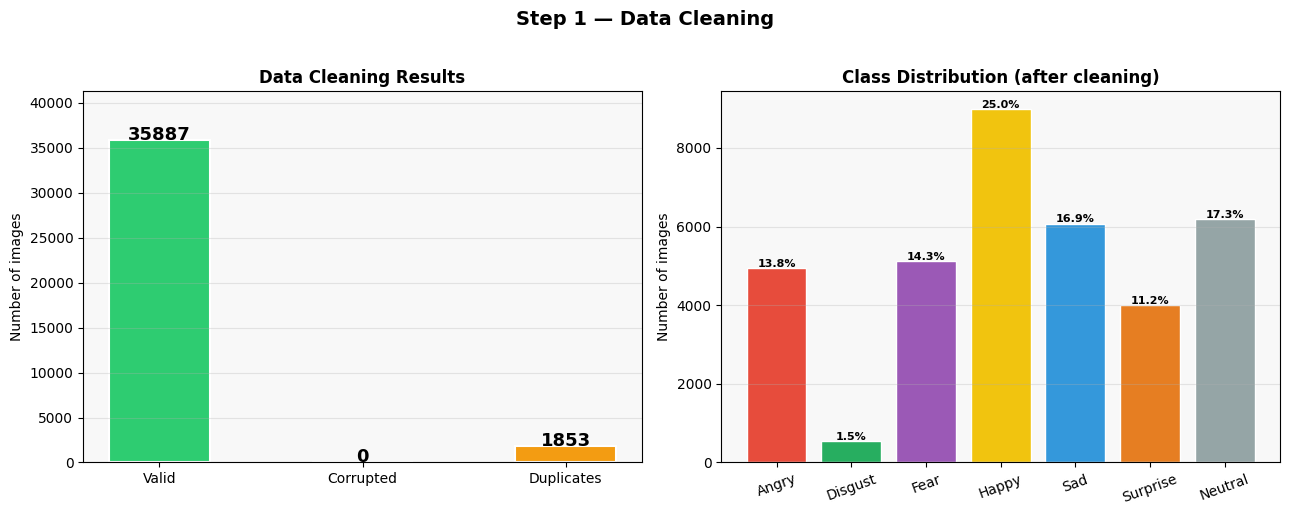

In [4]:
labels = ['Valid', 'Corrupted', 'Duplicates']
values = [stats['valid'], stats['corrupted'], stats['duplicates']]
colors = ['#2ecc71', '#e74c3c', '#f39c12']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Cleaning results
bars = ax1.bar(labels, values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontsize=13, fontweight='bold')
ax1.set_title("Data Cleaning Results")
ax1.set_ylabel("Number of images")
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, max(values) * 1.15)

# Class distribution
dist = stats['label_distribution']
class_counts = [dist.get(i, 0) for i in range(7)]
bar_colors = ['#e74c3c','#27ae60','#9b59b6','#f1c40f','#3498db','#e67e22','#95a5a6']
bars2 = ax2.bar(CLASS_NAMES, class_counts, color=bar_colors, edgecolor='white', linewidth=1)
total = sum(class_counts)
for bar, cnt in zip(bars2, class_counts):
    pct = 100 * cnt / total if total > 0 else 0
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{pct:.1f}%', ha='center', fontsize=8, fontweight='bold')
ax2.set_title("Class Distribution (after cleaning)")
ax2.set_ylabel("Number of images")
ax2.tick_params(axis='x', rotation=20)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle("Step 1 — Data Cleaning", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'cr2_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Warning: Class imbalance — Disgust ({class_counts[1]}) vs Happy ({class_counts[3]}) — ratio 1:{class_counts[3]//max(class_counts[1],1)}")

---
## 2. Resizing
All FER2013 images are already 48×48. We illustrate the effect of resizing from different resolutions.

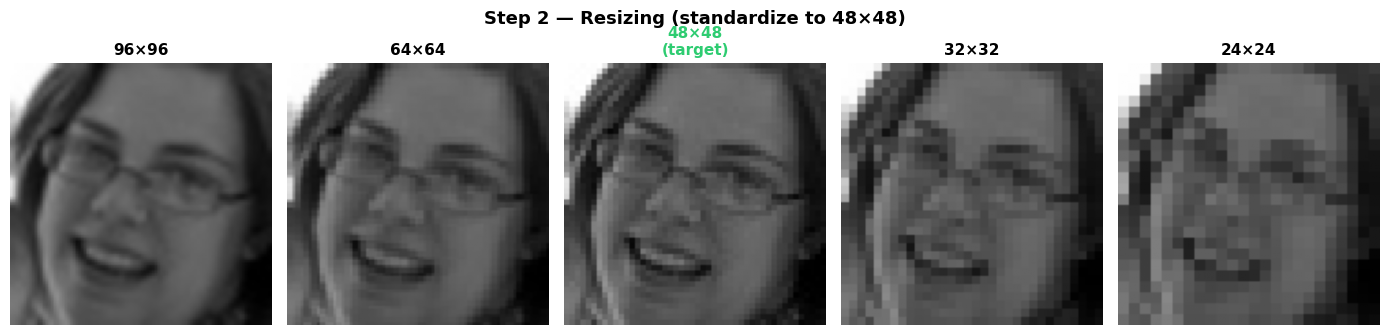

In [5]:
# Load one image per class
ds = FERDataset(str(DATA_ROOT), split='train', transform=None)

class_samples = {}
for idx, label in enumerate(ds.labels):
    if label not in class_samples:
        class_samples[label] = ds.images[idx]
    if len(class_samples) == 7:
        break

# Show different resolutions → 48×48
sample = class_samples[3]  # Happy
sizes = [96, 64, 48, 32, 24]
size_labels = ['96×96', '64×64', '48×48\n(target)', '32×32', '24×24']

fig, axes = plt.subplots(1, len(sizes), figsize=(14, 3.5))

for ax, size, label in zip(axes, sizes, size_labels):
    resized = cv2.resize(sample, (size, size))
    display = cv2.resize(resized, (96, 96), interpolation=cv2.INTER_NEAREST)
    ax.imshow(display, cmap='gray', vmin=0, vmax=255)
    color = '#2ecc71' if size == 48 else 'black'
    ax.set_title(label, fontsize=11, color=color)
    ax.axis('off')
    if size == 48:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('#2ecc71')
            spine.set_linewidth(3)

plt.suptitle("Step 2 — Resizing (standardize to 48×48)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'cr2_resizing.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Gaussian Denoising
Gaussian filter: kernel 3×3, σ = 0.8 — reduces high-frequency noise while preserving edges.

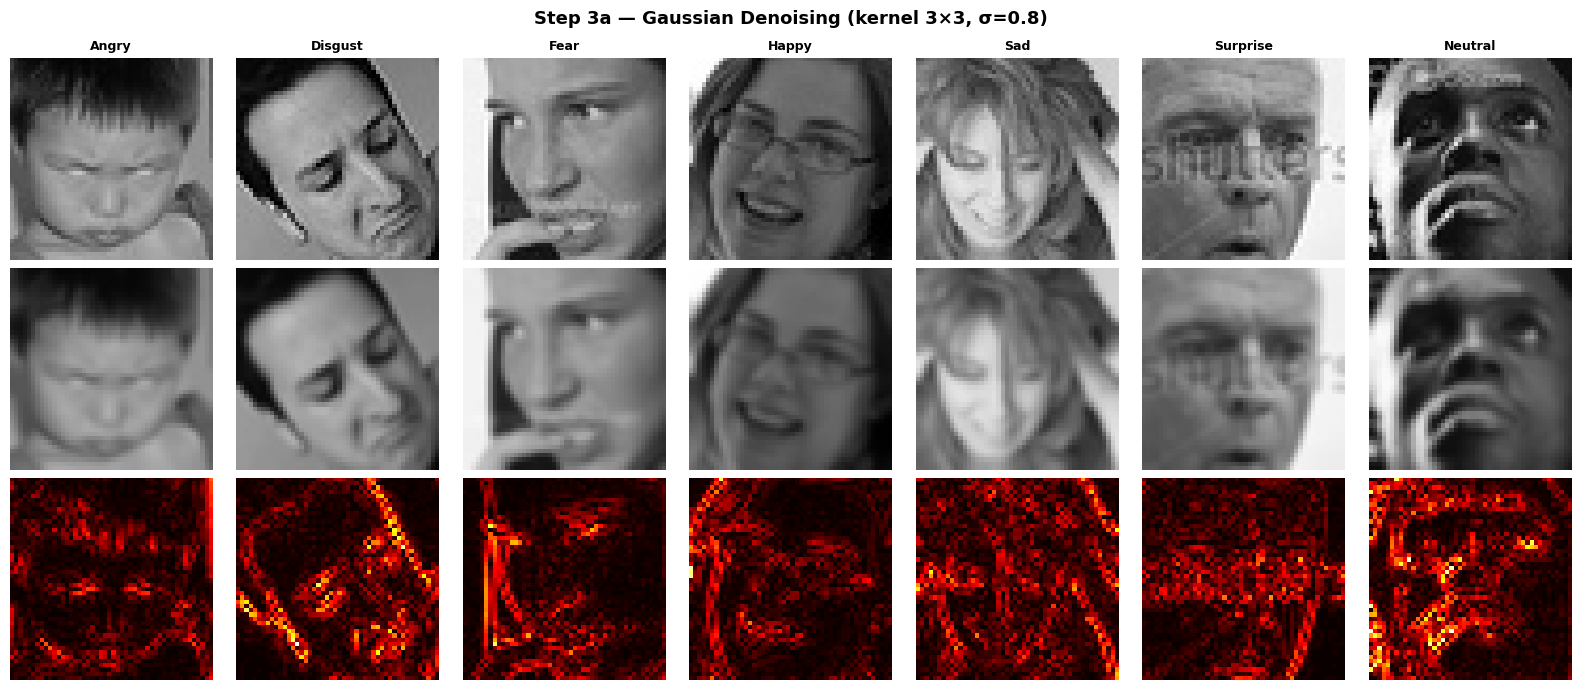

In [6]:
# Before / After denoising for each class
fig, axes = plt.subplots(3, 7, figsize=(16, 7))

for col, class_idx in enumerate(range(7)):
    img = class_samples[class_idx]
    denoised = denoise_gaussian(img)
    diff = np.abs(img.astype(int) - denoised.astype(int)).astype(np.uint8)

    # Row 0: Original
    axes[0, col].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title(CLASS_NAMES[col], fontsize=9)
    axes[0, col].axis('off')

    # Row 1: Denoised
    axes[1, col].imshow(denoised, cmap='gray', vmin=0, vmax=255)
    axes[1, col].axis('off')

    # Row 2: Difference (amplified x4)
    axes[2, col].imshow(np.clip(diff * 4, 0, 255), cmap='hot', vmin=0, vmax=255)
    axes[2, col].axis('off')

for row, label in enumerate(['Original', 'Denoised\n(Gaussian σ=0.8)', 'Difference\n(×4)']):
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=0, labelpad=70, va='center')

plt.suptitle("Step 3a — Gaussian Denoising (kernel 3×3, σ=0.8)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'cr2_denoising.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. CLAHE — Contrast Enhancement
**CLAHE** (Contrast Limited Adaptive Histogram Equalization) — clipLimit=2.0, tileGridSize=(4,4).

Improves visibility of facial details without over-amplifying noise.

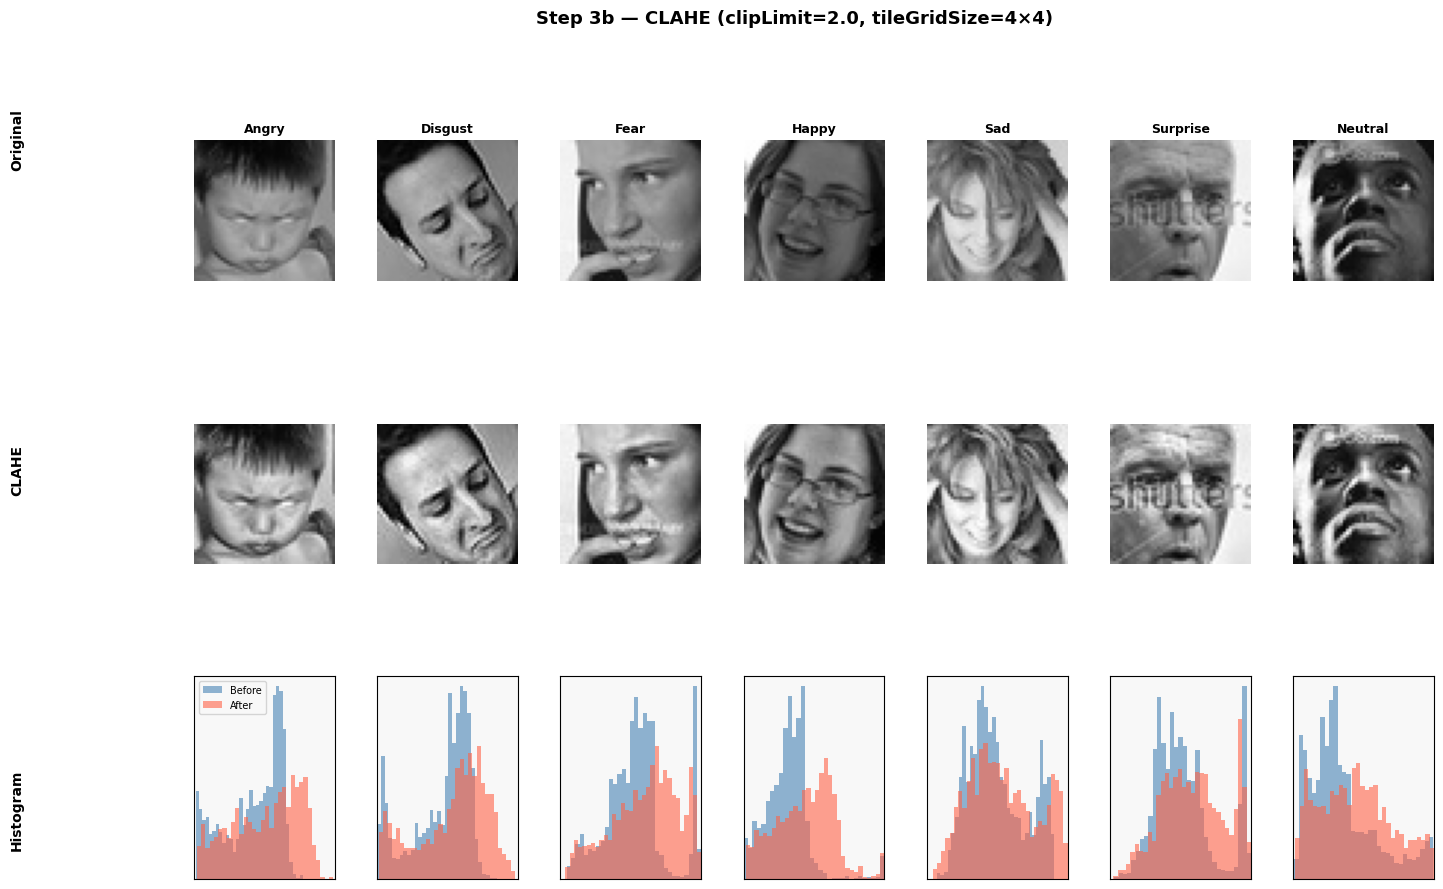

In [7]:
# Before / After CLAHE with histograms
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(3, 7, figure=fig, hspace=0.4, wspace=0.3)

for col, class_idx in enumerate(range(7)):
    img = class_samples[class_idx]
    clahe_img = apply_clahe(img)

    # Row 0: Original
    ax0 = fig.add_subplot(gs[0, col])
    ax0.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax0.set_title(CLASS_NAMES[col], fontsize=9)
    ax0.axis('off')

    # Row 1: CLAHE
    ax1 = fig.add_subplot(gs[1, col])
    ax1.imshow(clahe_img, cmap='gray', vmin=0, vmax=255)
    ax1.axis('off')

    # Row 2: Histogram comparison
    ax2 = fig.add_subplot(gs[2, col])
    ax2.hist(img.flatten(), bins=32, alpha=0.6, color='steelblue', density=True, label='Before')
    ax2.hist(clahe_img.flatten(), bins=32, alpha=0.6, color='tomato', density=True, label='After')
    ax2.set_xlim(0, 255)
    ax2.set_xticks([])
    ax2.set_yticks([])
    if col == 0:
        ax2.legend(fontsize=7)

fig.text(0.01, 0.85, 'Original', va='center', rotation=90, fontsize=10, fontweight='bold')
fig.text(0.01, 0.52, 'CLAHE', va='center', rotation=90, fontsize=10, fontweight='bold')
fig.text(0.01, 0.18, 'Histogram', va='center', rotation=90, fontsize=10, fontweight='bold')

plt.suptitle("Step 3b — CLAHE (clipLimit=2.0, tileGridSize=4×4)", fontsize=13, fontweight='bold')
plt.savefig(ROOT / 'results' / 'cr2_clahe.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Full Pipeline — Before / After Comparison

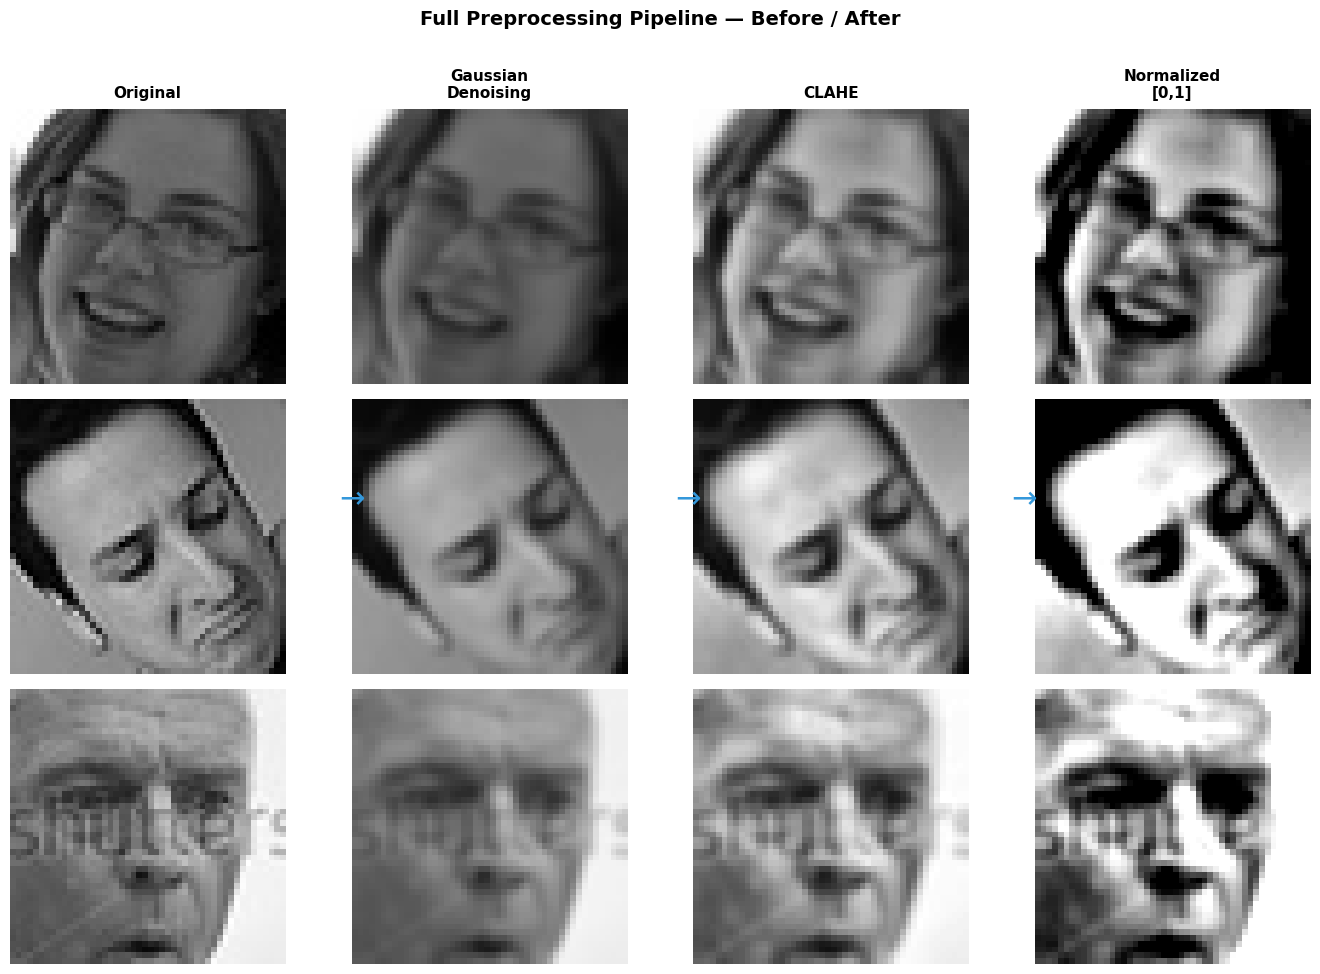

In [8]:
steps = {
    'Original': lambda img: img,
    'Gaussian\nDenoising': denoise_gaussian,
    'CLAHE': lambda img: apply_clahe(denoise_gaussian(img)),
    'Normalized\n[0,1]': lambda img: ((apply_clahe(denoise_gaussian(img)).astype(float) - 129.2) / 65.0 * 127 + 127).clip(0, 255).astype(np.uint8),
}

sample_indices = [3, 1, 5]  # Happy, Disgust, Surprise
sample_classes = [class_samples[i] for i in sample_indices]
sample_names   = [CLASS_NAMES[i] for i in sample_indices]

fig, axes = plt.subplots(len(sample_indices), len(steps),
                          figsize=(len(steps) * 3.5, len(sample_indices) * 3.2))

for row, (img, name) in enumerate(zip(sample_classes, sample_names)):
    for col, (step_name, fn) in enumerate(steps.items()):
        ax = axes[row, col]
        processed = fn(img)
        ax.imshow(processed, cmap='gray', vmin=0, vmax=255)
        ax.axis('off')
        if row == 0:
            ax.set_title(step_name, fontsize=11, pad=8)
        if col == 0:
            ax.set_ylabel(name, fontsize=11, rotation=0, labelpad=55, va='center')

fig.text(0.28, 0.5, '→', fontsize=22, ha='center', va='center', color='#3498db')
fig.text(0.52, 0.5, '→', fontsize=22, ha='center', va='center', color='#3498db')
fig.text(0.76, 0.5, '→', fontsize=22, ha='center', va='center', color='#3498db')

plt.suptitle("Full Preprocessing Pipeline — Before / After", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'cr2_full_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Normalization — Train Set Statistics

Statistics computed on TRAIN SET only (no data leakage)
  Mean : 0.5077  (config: 0.507)
  Std  : 0.2551  (config: 0.255)


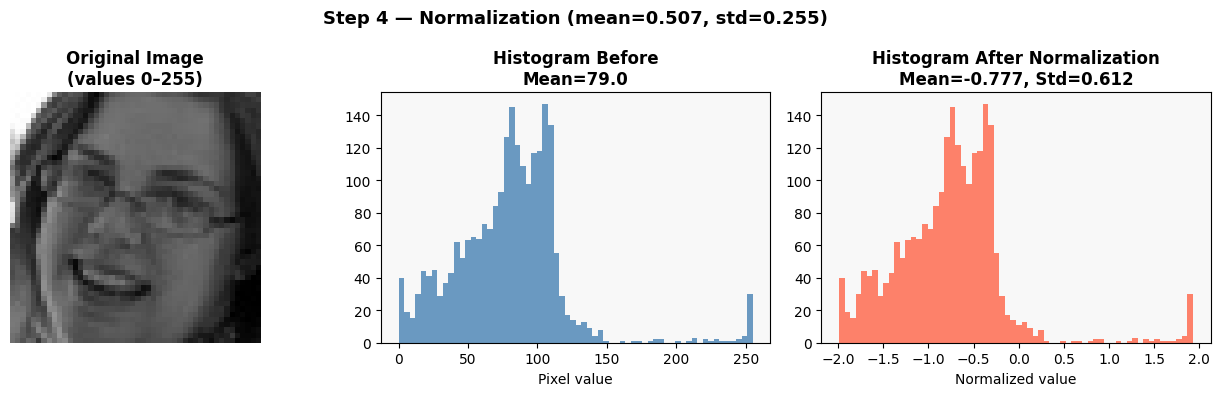

In [9]:
# Compute pixel statistics on train set only (no data leakage)
all_pixels = np.concatenate([img.flatten().astype(float) for img in ds.images])

mean_val = all_pixels.mean() / 255
std_val  = all_pixels.std()  / 255

print("Statistics computed on TRAIN SET only (no data leakage)")
print(f"  Mean : {mean_val:.4f}  (config: 0.507)")
print(f"  Std  : {std_val:.4f}  (config: 0.255)")

sample_img = class_samples[3].astype(float)
normalized = (sample_img / 255.0 - mean_val) / std_val

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(class_samples[3], cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image\n(values 0–255)')
axes[0].axis('off')

axes[1].hist(class_samples[3].flatten(), bins=64, color='steelblue', alpha=0.8)
axes[1].set_title(f'Histogram Before\nMean={class_samples[3].mean():.1f}')
axes[1].set_xlabel('Pixel value')

axes[2].hist(normalized.flatten(), bins=64, color='tomato', alpha=0.8)
axes[2].set_title(f'Histogram After Normalization\nMean={normalized.mean():.3f}, Std={normalized.std():.3f}')
axes[2].set_xlabel('Normalized value')

plt.suptitle("Step 4 — Normalization (mean=0.507, std=0.255)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'cr2_normalization.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Pipeline Summary

In [10]:
print("=" * 55)
print("PREPROCESSING PIPELINE — SUMMARY")
print("=" * 55)
print()
print("STEP 1 — Data Cleaning")
print(f"  Total images : {stats['total']}")
print(f"  Valid        : {stats['valid']}")
print(f"  Corrupted    : {stats['corrupted']}")
print(f"  Duplicates   : {stats['duplicates']}")
print()
print("STEP 2 — Resizing")
print("  Target size  : 48×48 pixels (grayscale)")
print()
print("STEP 3a — Gaussian Denoising")
print("  Kernel       : 3×3")
print("  Sigma        : 0.8")
print()
print("STEP 3b — CLAHE")
print("  clipLimit    : 2.0")
print("  tileGridSize : (4, 4)")
print()
print("STEP 4 — Normalization")
print(f"  Mean         : {mean_val:.4f}")
print(f"  Std          : {std_val:.4f}")
print("  Computed on  : Train set only (no data leakage)")
print("=" * 55)
print("\nFigures saved in results/")

PREPROCESSING PIPELINE — SUMMARY

STEP 1 — Data Cleaning
  Total images : 35887
  Valid        : 35887
  Corrupted    : 0
  Duplicates   : 1853

STEP 2 — Resizing
  Target size  : 48×48 pixels (grayscale)

STEP 3a — Gaussian Denoising
  Kernel       : 3×3
  Sigma        : 0.8

STEP 3b — CLAHE
  clipLimit    : 2.0
  tileGridSize : (4, 4)

STEP 4 — Normalization
  Mean         : 0.5077
  Std          : 0.2551
  Computed on  : Train set only (no data leakage)

Figures saved in results/
